In [1]:
%run ../../../bootstrap.py

[Bootstrap] cwd=/home/ikk/renal-calculi-classificaction | seed=57


In [2]:
from src.data.dataset_builder import DatasetBuilder, assign_task_labels
# import src.models.xgboost_model as xgb
from src.features.feature_extractor import FeatureExtractor
from src.data.dataset import KidneyStoneDataset
from src.features.lbp import LocalBinaryPattern
from src.features.hsv import HSV_extractor
import pandas as pd
from src.pipelines.xgboost_pipeline import XGBoostExperiment
builder = DatasetBuilder(root_path= DATASET_PATH_XGBOOST)
lbp = LocalBinaryPattern()
hsv = HSV_extractor()
extractor = FeatureExtractor(hsv, lbp)


In [4]:
results= []

patches_df_full = pd.read_csv(f"experiments/patches_{PATCH_SIZE}_metadata.csv")

task_name = "binario"
task_config = TASKS[task_name]

patches_task = assign_task_labels(patches_df_full, task_config)
xgboost_model= XGBoostExperiment(patches_task, extractor, Case.PATCH)


  Features shape: (5290, 40)
  Distribución: {0: 2767, 1: 2523}


In [5]:

print(f"  patches: {len(patches_task)}")
print(f"  imágenes: {patches_task['source_image'].nunique()}")
print(f"  distribución: {patches_task['label'].value_counts().to_dict()}")

config = {
    "name": f"patches_xgboost_{task_name}",
    "output_dir": f"experiments/xgboost/xgboost_patches/xgboost_{task_name}",
    "class_names": task_config["class_names"],
}
result= xgboost_model.search_hyperparameters(config)


  patches: 5290
  imágenes: 396
  distribución: {0: 2767, 1: 2523}

BÚSQUEDA HP: patches_xgboost_binario
  use_sample_weight = False


  0%|          | 0/100 [00:00<?, ?it/s]

  CV score: 0.8762
  Best params: {'max_depth': 9, 'min_child_weight': 1, 'n_estimators': 505, 'learning_rate': 0.019936189031515384, 'subsample': 0.6575599380281486, 'colsample_bytree': 0.7074138588195525}



EVALUACIÓN CV: patches_xgboost_binario (5 folds)
  use_augmentation = False
  Fold 1: accuracy=0.8337 | precision_weighted=0.8359 | recall_weighted=0.8337 | f1_weighted=0.8337 | specificity_weighted=0.8360 | npv_weighted=0.8334 | auc_weighted=0.8996
  Fold 2: accuracy=0.7758 | precision_weighted=0.7792 | recall_weighted=0.7758 | f1_weighted=0.7764 | specificity_weighted=0.7788 | npv_weighted=0.7696 | auc_weighted=0.8643
  Fold 3: accuracy=0.8130 | precision_weighted=0.8160 | recall_weighted=0.8130 | f1_weighted=0.8134 | specificity_weighted=0.8167 | npv_weighted=0.8086 | auc_weighted=0.8731
  Fold 4: accuracy=0.7827 | precision_weighted=0.8149 | recall_weighted=0.7827 | f1_weighted=0.7858 | specificity_weighted=0.8218 | npv_weighted=0.7549 | auc_weighted=0.8832
  Fold 5: accuracy=0.7937 | precision_weighted=0.7938 | recall_weighted=0.7937 | f1_weighted=0.7937 | specificity_weighted=0.7928 | npv_weighted=0.7923 | auc_weighted=0.8606

RESULTADOS CV 5 -fold (media ± std entre folds):
  a

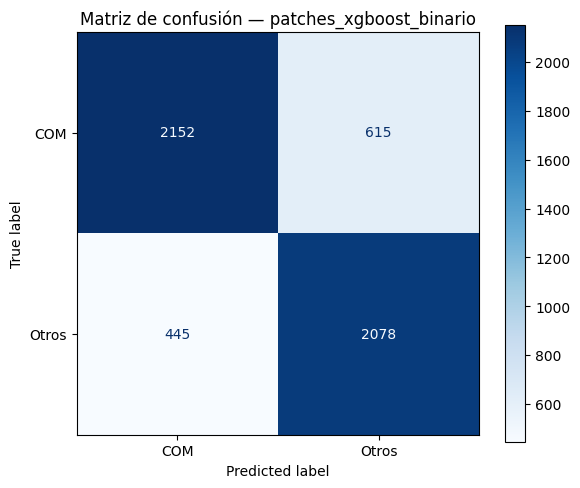


 Métricas agregadas a nivel imagen (media ± std entre folds):

RESULTADOS CV 5 -fold (media ± std entre folds):
  accuracy: 0.8379 ± 0.0512
  auc_weighted: 0.9244 ± 0.0308
  f1_weighted: 0.8384 ± 0.0507
  npv_weighted: 0.8306 ± 0.0572
  precision_weighted: 0.8442 ± 0.0503
  recall_weighted: 0.8379 ± 0.0512
  specificity_weighted: 0.8426 ± 0.0508


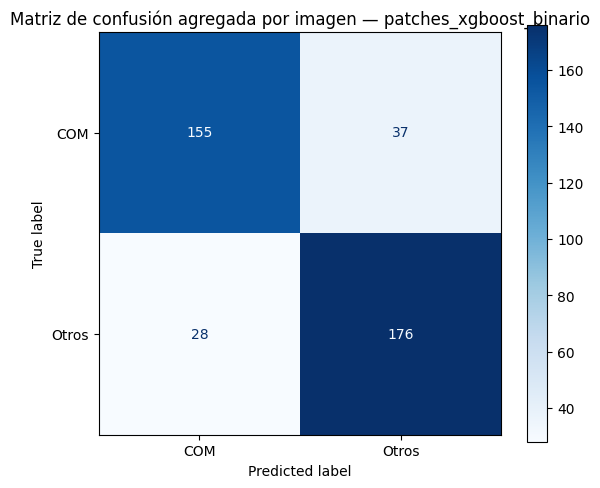

In [6]:
# import json
# with open("experiments/xgboost/xgboost_patches/patches_xgboost_binary_mixed/best_params.json") as f:
#     best_params= json.load(f)
eval_result= xgboost_model.evaluate_cv(config, result["best_params"], show_fold_metrics= True)
results.append(eval_result)
    
